In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt
import sys
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from swiss_roll_models.environment.dataset import generate_swiss_roll
from swiss_roll_models.environment.hilbert_distance import hilbert_analysis as hda

# positive linear model = softplus(theta) ∈ R^D_{>0}
class PositiveLinear(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(D))  # trainable parameters
    def forward(self, X):
        w = F.softplus(self.theta)
        return X @ w

    def positive_params_vector(self):
        # Return the current positive parameter vector for Hilbert distance calculation
        return F.softplus(self.theta).detach().clone()


In [2]:
def run_experiment_on_subset(
    X_full, y_full, n,
    num_epochs=500,
    lr=1e-2,
    l2_reg=1e-3,
    device="cuda"
):
    N, D = X_full.shape
    idx = torch.randperm(N, device=device)[:n]
    X = X_full[idx]
    y = y_full[idx]

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=n, shuffle=False)  # full-batch

    model = PositiveLinear(D).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    param_traj = []
    loss_traj = []

    for epoch in range(num_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            # 1. prediction
            y_pred = model(batch_X)

            # 2. MSE part
            mse = F.mse_loss(y_pred, batch_y)

            # 3. L2 regularization: regularize w = softplus(theta) in the positive cone
            w = F.softplus(model.theta)
            l2 = (w ** 2).sum()

            # 4. Total loss = mse + λ ||w||^2
            loss = mse + l2_reg * l2

            loss.backward()
            optimizer.step()

        loss_traj.append(loss.item())
        param_traj.append(model.positive_params_vector().cpu())

    w_star = param_traj[-1]

    prev = param_traj[0]
    return {
        "n": n,
        "loss_traj": loss_traj,
        "param_traj": param_traj,
        "w_star": w_star,
    }


Using device: cuda
Full dataset: X=torch.Size([10000, 32]), y=torch.Size([10000])

================ n = 50 ================

--- Running experiment (n=50, l2_reg=0.0001) ---
Final loss: 0.001835
Initial d_H(w_t, w*): 0.179794
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.3789351015212292, 0.42177653653997194, 0.423991836478647, 0.42873375512456807, 0.4282321781207104, 0.42888893699528463, 0.4287476506455072, 0.4281419881515217, 0.4278384409313264, 0.43723529677937034, 0.6906320484824107, 0.818374545473592, 0.8934098165864253, 0.9577496656094121, 0.9721098269091835]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.3789351015212292, 0.15982593469304673, 0.06776489156742119, 0.029053096427309664, 0.012441470764217848, 0.0053360091707233045, 0.002287801395770498, 0.0009795038380810074, 0.0004190693949708286, 0.00018323193128122142, 0.00012654584404813826, 0.00010356189760446719, 9.25232159441492e-05, 8.861407913161631e-05]
First 15 d_H(w_t, w*): [0.179794

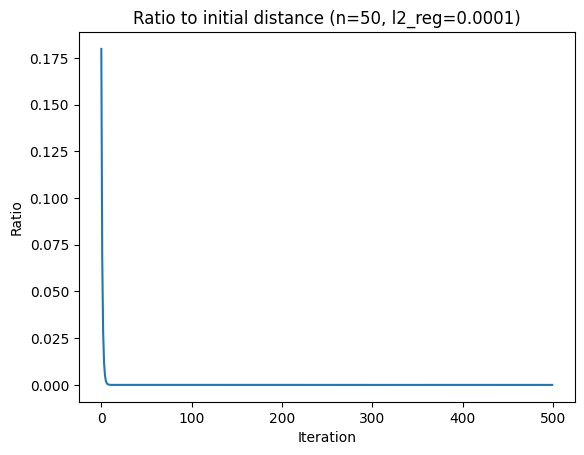


--- Running experiment (n=50, l2_reg=0.1) ---
Final loss: 0.995762
Initial d_H(w_t, w*): 0.279854
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.5137307172059715, 0.5006780717650626, 0.5102103839894033, 0.5273860349081186, 0.5553223418396501, 0.6337539438392463, 0.776183942941161, 0.9050437978264454, 0.9461035211304992, 0.9700466940292581, 1.0011850265591844, 1.0034694787162586, 1.0003595472462938, 0.998830412348663, 0.9980178955861747]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.5137307172059715, 0.25721370489716855, 0.13123310314292141, 0.06921050591523349, 0.03843414022475442, 0.024357787945508733, 0.018906123888869652, 0.017110870166559874, 0.016188654514189108, 0.01570375079227097, 0.015722360154038627, 0.015776908547962414, 0.015782581091985864, 0.015764121980034452]
First 15 d_H(w_t, w*): [0.279853798440459, 0.1437694925856324, 0.0719822323264159, 0.0367260823956751, 0.019368822972363947, 0.010755940131690761, 0.006816619478157843, 0.00529

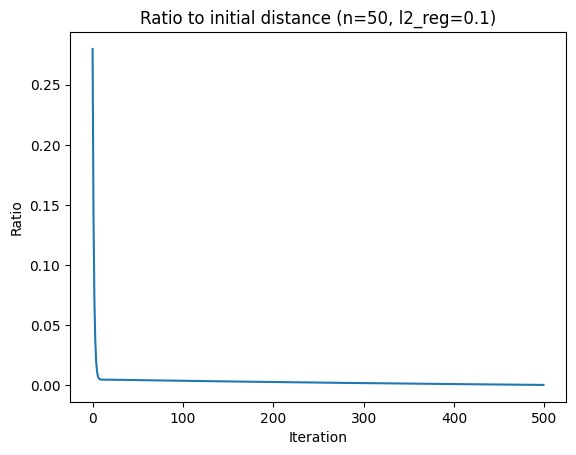


================ n = 100 ================

--- Running experiment (n=100, l2_reg=0.0001) ---
Final loss: 0.001934
Initial d_H(w_t, w*): 0.156357
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.5065370235460509, 0.5089671226936144, 0.5160137861906752, 0.5209987398150827, 0.5237003053961822, 0.5250861673097311, 0.5257916934034499, 0.5262985738458428, 0.5269404258287103, 0.5270387994692984, 0.5291190043590438, 0.5325022069886401, 0.5347163215771742, 0.5435004846490848, 0.5611982491835307]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.5065370235460509, 0.2578106914120212, 0.13303387099595282, 0.06931047914161372, 0.03629791909361881, 0.019059535218187013, 0.010021345297853241, 0.005274219738276903, 0.00277919959480182, 0.0014647460179299117, 0.000775024954645949, 0.00041270249882023857, 0.00022067876207486602, 0.00011993901413944977]
First 15 d_H(w_t, w*): [0.15635663572714945, 0.0792004248729044, 0.04031041236367393, 0.020800728506686787, 0.01083715333

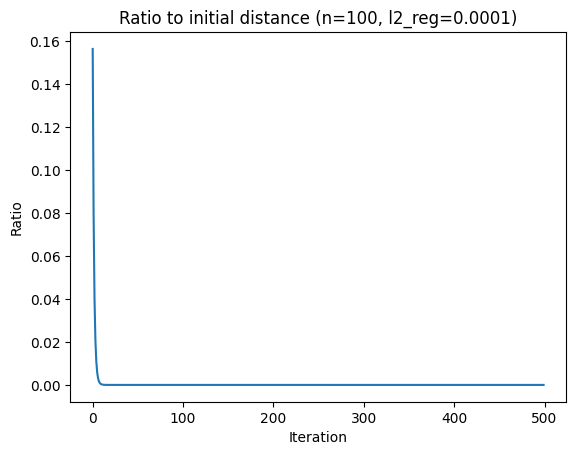


--- Running experiment (n=100, l2_reg=0.1) ---
Final loss: 0.992377
Initial d_H(w_t, w*): 0.165231
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.47054922188010634, 0.48221103627569334, 0.48037022710695093, 0.4863869037578762, 0.6386961366001033, 0.8777526836165596, 0.9369357229549287, 1.043680459403932, 1.0185689894181902, 1.0073362455626775, 1.0021165991634604, 0.9996763715183821, 0.9985287362153389, 0.9979612743458057, 0.9977039688642197]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.47054922188010634, 0.22690402790152725, 0.10899793941453857, 0.053015170267825984, 0.03386058443125712, 0.029721218853361032, 0.027846871673475472, 0.029063235821135222, 0.02960291073955625, 0.02982008496211166, 0.029883202128996787, 0.029873531073665895, 0.029829579229277266, 0.029768764900848718]
First 15 d_H(w_t, w*): [0.16523058071965827, 0.0777491211884333, 0.03749148429779889, 0.018009792826710336, 0.008759727370304449, 0.005594804029083633, 0.0049108542508368

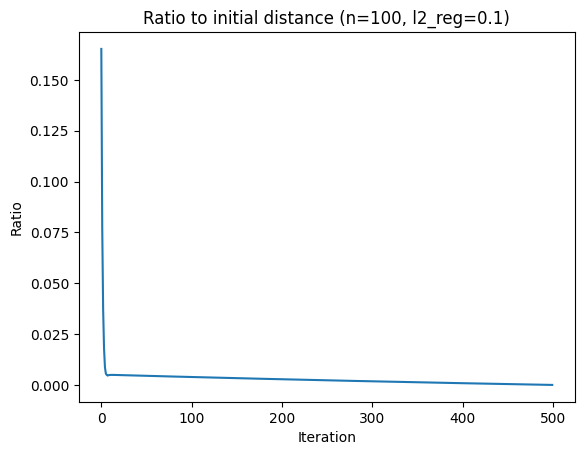


================ n = 200 ================

--- Running experiment (n=200, l2_reg=0.0001) ---
Final loss: 0.001908
Initial d_H(w_t, w*): 0.220352
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.48982809959900514, 0.48051697579102076, 0.4707200468381422, 0.46939423924659157, 0.4697537774286844, 0.4701723935630004, 0.4704542071316858, 0.47061170879676595, 0.4707336420469139, 0.470626642629356, 0.47283581672432257, 0.4756712946120055, 0.4877636358186385, 0.4969974804368596, 0.6385049332358449]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.48982809959900514, 0.23537071707677687, 0.11079371496670753, 0.052005931550101386, 0.02442998279435772, 0.011486303485126087, 0.005403779798968913, 0.0025430820451542045, 0.001197114273139553, 0.0005633938712113497, 0.00026639280123169634, 0.00012671540863719966, 6.180716843112502e-05, 3.071800698320574e-05]
First 15 d_H(w_t, w*): [0.2203519658225655, 0.10793458466177219, 0.05186440020493467, 0.024413612893699, 0.01145

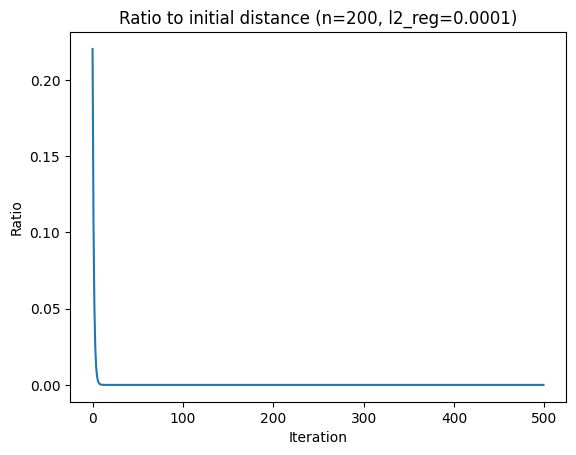


--- Running experiment (n=200, l2_reg=0.1) ---
Final loss: 0.981183
Initial d_H(w_t, w*): 0.206868
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.3046359129829703, 0.5136845625941869, 0.5195064247966534, 0.644555166396132, 0.8794513515114695, 0.9363808490082366, 0.9677702733924886, 0.9835029362365191, 0.9909671154908621, 0.9944790869024366, 0.9960793203960058, 0.9968204004478929, 0.9971456018104543, 0.997296758213861, 0.9973776338945899]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.3046359129829703, 0.1564867657111379, 0.0812958801825848, 0.052399679578405946, 0.046082969023997056, 0.04315120965951063, 0.04176045796940119, 0.04107153303148782, 0.040700538617001146, 0.04047583448027266, 0.04031714170157121, 0.040188949335874656, 0.04007423407165059, 0.03996590372756059]
First 15 d_H(w_t, w*): [0.20686768639476416, 0.06301932651154377, 0.03237205517406261, 0.016817490646797273, 0.010839800482211809, 0.009533077184195854, 0.008926590907398363, 0.0086

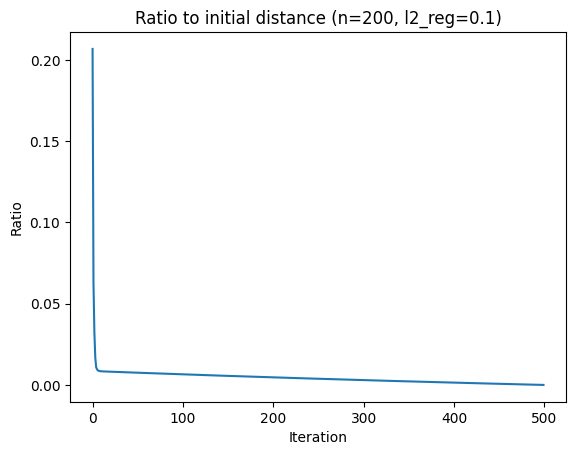


================ n = 500 ================

--- Running experiment (n=500, l2_reg=0.0001) ---
Final loss: 0.001955
Initial d_H(w_t, w*): 0.207306
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.47651400400204996, 0.4782242985860369, 0.4768435508176996, 0.4766640695552946, 0.4767873634984343, 0.4769571495212662, 0.477208151537858, 0.47768496085590734, 0.4787031812656355, 0.48049014925125666, 0.48355647369963134, 0.4949325720661083, 0.5089220786357717, 0.5339185679740155, 0.8286572538866364]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.47651400400204996, 0.2278805753303043, 0.10866338270288257, 0.051795930210800416, 0.024695645005156433, 0.011778764447248508, 0.0056209224092713, 0.0026850301010468533, 0.0012853324511651193, 0.0006175895812978118, 0.0002986394401260017, 0.00014780638622194456, 7.52219333117137e-05, 4.016238691402707e-05]
First 15 d_H(w_t, w*): [0.20730552869104402, 0.09878398752833123, 0.04724090314726802, 0.02252652000057832, 0.010737

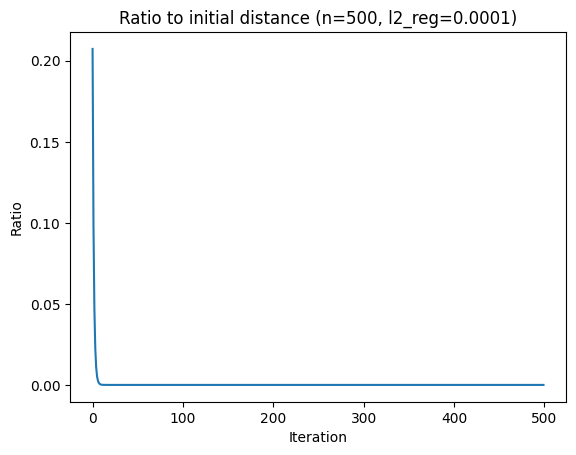


--- Running experiment (n=500, l2_reg=0.1) ---
Final loss: 0.991797
Initial d_H(w_t, w*): 0.158743
Final   d_H(w_t, w*): 0.000000
First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*): [0.3457704211468976, 0.42053953476424494, 0.4312110008998775, 0.4535760607309469, 0.5987671488897074, 0.9677703832580336, 1.0207762999934786, 1.0067378164061944, 1.0012579222653484, 0.9990646874218452, 0.9981726830846996, 0.9977794892298859, 0.9976369548323263, 0.9975444825751502, 0.9975504139071397]
First 15 ratio d_H(w_t, w*)/d_H(w_0, w*): [1.0, 0.3457704211468976, 0.14541013204435335, 0.06270244857982897, 0.02844032962502358, 0.01702913508305885, 0.01648029258588469, 0.01682269208862933, 0.01693604029938045, 0.016957344521559878, 0.016941484103936758, 0.01691052664346334, 0.016872976636923227, 0.016833105031017075, 0.016791771048299084]
First 15 d_H(w_t, w*): [0.15874323649479588, 0.05488871573702714, 0.023082874979856283, 0.009953589623710568, 0.004514709971655068, 0.0027032600177918364, 0.002616134983464524

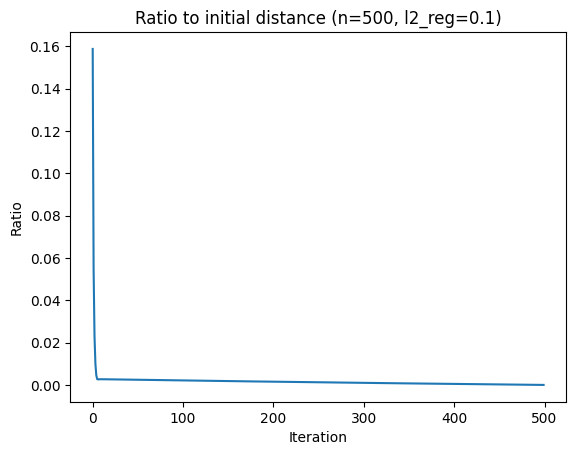

In [3]:
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    # ----- Generate Swiss roll -----
    N = 10_000
    D = 32
    X_full, y_full, u, v = generate_swiss_roll(
        n_samples=N,
        D=D,
        noise=0.0,
        device=device,
    )
    print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")

    # ----- Different small sample sizes -----
    n_list = [50, 100, 200, 500]
    num_epochs = 500
    lr = 1e-2
    l2_list = [1e-4, 1e-1]

    # all_results[n][l2_reg] = corresponding experiment results
    all_results = {}

    for n in n_list:
        all_results[n] = {}
        print(f"\n================ n = {n} ================")

        for l2_reg in l2_list:
            print(f"\n--- Running experiment (n={n}, l2_reg={l2_reg}) ---")
            res = run_experiment_on_subset(
                X_full,
                y_full,
                n=n,
                num_epochs=num_epochs,
                lr=lr,
                l2_reg=l2_reg,
                device=device,
            )
            all_results[n][l2_reg] = res
            analysis= hda.analysis_distance_on_cone(res["param_traj"], res["w_star"])
            hilbert_to_final=analysis["hilbert_to_final"]
            hilbert_to_init=analysis["hilbert_to_init"]
            hilbert_between=analysis["hilbert_between"]
            print(f"Final loss: {res['loss_traj'][-1]:.6f}")
            print(f"Initial d_H(w_t, w*): {hilbert_to_final[0]:.6f}")
            print(f"Final   d_H(w_t, w*): {hilbert_to_final[-1]:.6f}")

            hilbert = hilbert_to_final
            ratio_to_prev = [hilbert[i] / hilbert[i-1] if hilbert[i-1] != 0 else float("inf") for i in range(1, len(hilbert))]
            init_dist = hilbert[0]
            ratio_to_init = [d / init_dist if init_dist != 0 else float("inf") for d in hilbert]

            print("First 15 ratio d_H(w_t, w*)/d_H(w_{t-1}, w*):", ratio_to_prev[:15])
            print("First 15 ratio d_H(w_t, w*)/d_H(w_0, w*):", ratio_to_init[:15])
            hil= hilbert_to_final[:15]
            print("First 15 d_H(w_t, w*):", hil)
            print("First 15 d_H(w_t, w_0):", hilbert_to_init[:15])
            print("First 15 d_H(w_{t+1}, w_t):", hilbert_between[:15])
            #plot ratio to final
            print(type(hilbert_to_final))
            plt.plot(range(len(hilbert_to_final)), hilbert_to_final, label="d_H(w_t, w*)")
            plt.title(f"Ratio to initial distance (n={n}, l2_reg={l2_reg})")
            plt.xlabel("Iteration")
            plt.ylabel("Ratio")
            plt.show()
    torch.save(all_results, "swiss_roll_cone_l2_experiments.pt")

    
if __name__ == "__main__":
    main()

